# 🎵 Music Genre Classification - Version 3 (Advanced)

## 🎯 Goals
1. **Advanced Feature Engineering**: Log-transforms, correlation removal, feature selection.
2. **Multi-Model Training**: RF, LightGBM, XGBoost, CatBoost, SVM, KNN, Naive Bayes.
3. **Robust Evaluation**: 5-Fold Stratified Cross-Validation.
4. **Advanced Ensemble**: Weighted Soft-Voting & Stacking.
5. **Target Score**: > 0.55079

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Add src to path
sys.path.append(os.path.abspath("src"))

from preprocess.feature.feature import Feature
from pipeline.BasePipeline import BasePipeline
from model.Random_Forest import ModelRandomForest
from model.LightGBM import ModelLightGBM
from model.XGBoost import ModelXGBoost
from model.Catboost import ModelCatboost
from model.SVM import ModelSVM
from model.KNN import ModelKNN
from model.Naive_Bayes import ModelNaiveBayes
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, log_loss
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

## 1. Load Data

In [2]:
DATA_DIR = "data"
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sample_sub = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

# Encode Target
le = LabelEncoder()
train_df['Class_Encoded'] = le.fit_transform(train_df['Class'])
target_col = 'Class_Encoded'
original_target_col = 'Class'

classes = le.classes_
print(f"Classes: {classes}")

Train shape: (14396, 18)
Test shape: (3600, 17)
Classes: [ 0  1  2  3  4  5  6  7  8  9 10]


## 2. Feature Engineering & Preprocessing

In [3]:
# Combine for preprocessing
train_df['is_train'] = 1
test_df['is_train'] = 0
full_df = pd.concat([train_df.drop(columns=['Class', 'Class_Encoded']), test_df], axis=0).reset_index(drop=True)

# Drop ID and Name columns
drop_cols = ['Id', 'Artist Name', 'Track Name']
full_df = full_df.drop(columns=drop_cols)

# Handle Missing Values (Median Imputation)
numeric_cols = full_df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    full_df[col] = full_df[col].fillna(full_df[col].median())

# Feature Engineering: Log Transform for Skewed Features
skewed_features = ['Popularity', 'loudness', 'duration_in min/ms', 'tempo']
for col in skewed_features:
    if col in full_df.columns:
        # Shift to positive if needed
        min_val = full_df[col].min()
        shift = abs(min_val) + 1 if min_val <= 0 else 0
        full_df[f'{col}_log'] = np.log1p(full_df[col] + shift)

# Scaling (StandardScaler) - Important for SVM/KNN
scaler = StandardScaler()
scaled_cols = full_df.select_dtypes(include=np.number).columns.drop('is_train')
full_df[scaled_cols] = scaler.fit_transform(full_df[scaled_cols])

# Split back
X = full_df[full_df['is_train'] == 1].drop(columns=['is_train'])
X_test = full_df[full_df['is_train'] == 0].drop(columns=['is_train'])
y = train_df['Class_Encoded']

print(f"Processed Train X shape: {X.shape}")
print(f"Processed Test X shape: {X_test.shape}")

Processed Train X shape: (14396, 18)
Processed Test X shape: (3600, 18)


### Feature Selection

In [4]:
# Use Feature class to remove high correlation
ft = Feature(pd.concat([X, y.rename(target_col)], axis=1), target_col=target_col, task='classification')

# Remove correlation > 0.95
ft.correlation_analysis(threshold=0.95, show_report=True)

# Update X based on selection
X_selected = ft.get_data().drop(columns=[target_col])
X_test_selected = X_test[X_selected.columns]

print(f"Selected Features: {X_selected.columns.tolist()}")

## 🔬 Correlation Analysis (threshold=0.95)

**⚠️ High Correlation Pairs (>0.95)**

,Feature 1,Feature 2,Correlation
1,tempo_log,tempo,0.989640
0,loudness_log,loudness,0.979458


### ✅ Đã loại bỏ **2** features có correlation cao: ['loudness_log', 'tempo_log']

Selected Features: ['Popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_in min/ms', 'time_signature', 'Popularity_log', 'duration_in min/ms_log']


## 3. Model Training (5-Fold CV)

[I 2025-11-21 18:13:02,940] A new study created in memory with name: no-name-1242f367-f7a2-409a-8b7c-a4ac4b74e18d



==================== Training RandomForest ====================

🚀 Start CV run: RandomForest_V3_classification_CV_181302 (CV=5)

🔄 Fold 1/5
🔍 Đang tìm tham số tốt nhất cho Random Forest bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-21 18:13:06,407] Trial 0 finished with value: 0.5058696908202951 and parameters: {'n_estimators': 300, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_samples': 0.7900957872020753}. Best is trial 0 with value: 0.5058696908202951.
[I 2025-11-21 18:13:08,663] Trial 1 finished with value: 0.4706212924461611 and parameters: {'n_estimators': 400, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_samples': 0.7405679287749025}. Best is trial 0 with value: 0.5058696908202951.
[I 2025-11-21 18:13:12,217] Trial 2 finished with value: 0.5583468511110742 and parameters: {'n_estimators': 500, 'max_depth': 16, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'max_samples': 0.755042705997117}. Best is trial 2 with value: 0.5583468511110742.
[I 2025-11-21 18:13:17,283] Trial 3 finished with value: 0.5561381144116426 and parameters: {'n_estimators': 200, 'max_depth': 16, 'min_samples_spl

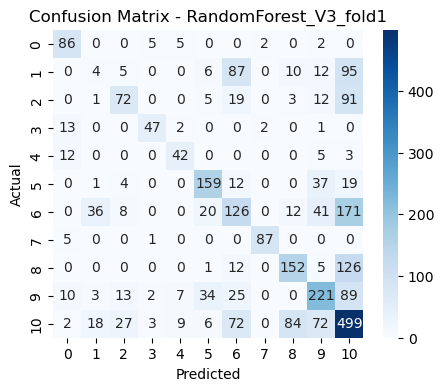

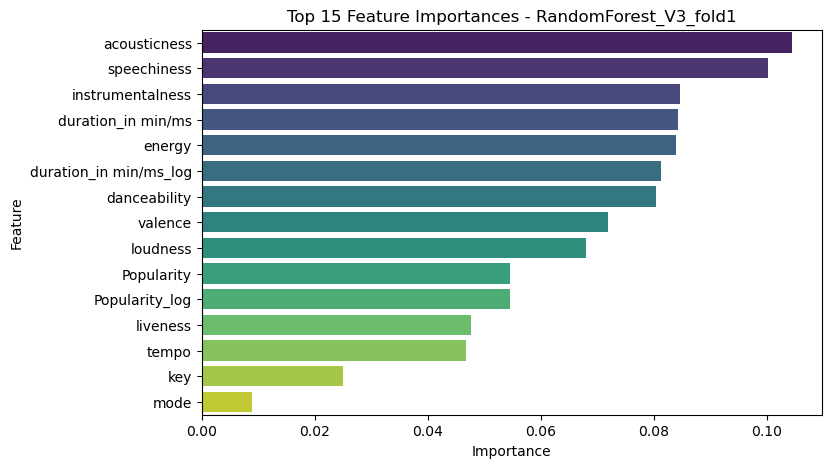

[I 2025-11-21 18:15:06,718] A new study created in memory with name: no-name-7cceccdd-1be3-4cc0-9ddb-1bcb9e73fdd6


💾 Model đã được lưu tại: experiments/models\RandomForest_V3_fold1_best.pkl

🔄 Fold 2/5
🔍 Đang tìm tham số tốt nhất cho Random Forest bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-21 18:15:09,268] Trial 0 finished with value: 0.47920582822241237 and parameters: {'n_estimators': 500, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 0.7, 'max_samples': 0.7639878902712269}. Best is trial 0 with value: 0.47920582822241237.
[I 2025-11-21 18:15:10,391] Trial 1 finished with value: 0.5597078940823531 and parameters: {'n_estimators': 200, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_samples': 0.7648084478562528}. Best is trial 1 with value: 0.5597078940823531.
[I 2025-11-21 18:15:11,074] Trial 2 finished with value: 0.5595032051922256 and parameters: {'n_estimators': 100, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_samples': 0.8640634614909197}. Best is trial 1 with value: 0.5597078940823531.
[I 2025-11-21 18:15:12,573] Trial 3 finished with value: 0.5452838666048735 and parameters: {'n_estimators': 200, 'max_depth': 9, 'min_samples_

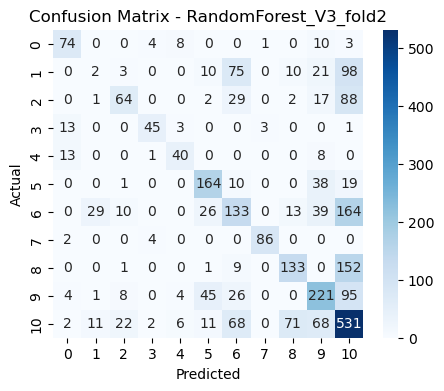

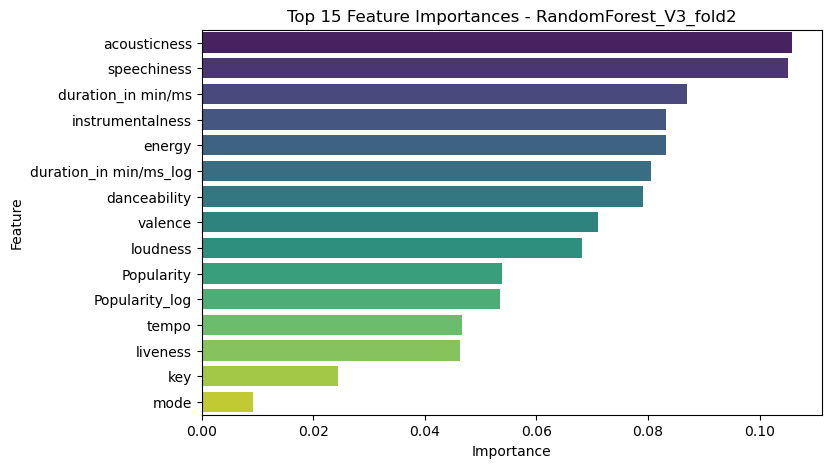

💾 Model đã được lưu tại: experiments/models\RandomForest_V3_fold2_best.pkl


[I 2025-11-21 18:16:02,940] A new study created in memory with name: no-name-aa477588-5526-42c0-ab20-437e438315e6



🔄 Fold 3/5
🔍 Đang tìm tham số tốt nhất cho Random Forest bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-21 18:16:08,130] Trial 0 finished with value: 0.5323362917358199 and parameters: {'n_estimators': 500, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_samples': 0.8340450191938892}. Best is trial 0 with value: 0.5323362917358199.
[I 2025-11-21 18:16:12,223] Trial 1 finished with value: 0.5576036795806063 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_samples': 0.9422138100014229}. Best is trial 1 with value: 0.5576036795806063.
[I 2025-11-21 18:16:25,297] Trial 2 finished with value: 0.5584061378677573 and parameters: {'n_estimators': 400, 'max_depth': 13, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 0.7, 'max_samples': 0.8552021346174548}. Best is trial 2 with value: 0.5584061378677573.
[I 2025-11-21 18:16:28,664] Trial 3 finished with value: 0.5544840217831047 and parameters: {'n_estimators': 100, 'max_depth': 14, 'min_samples_split

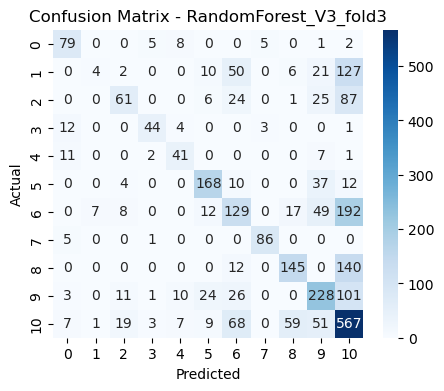

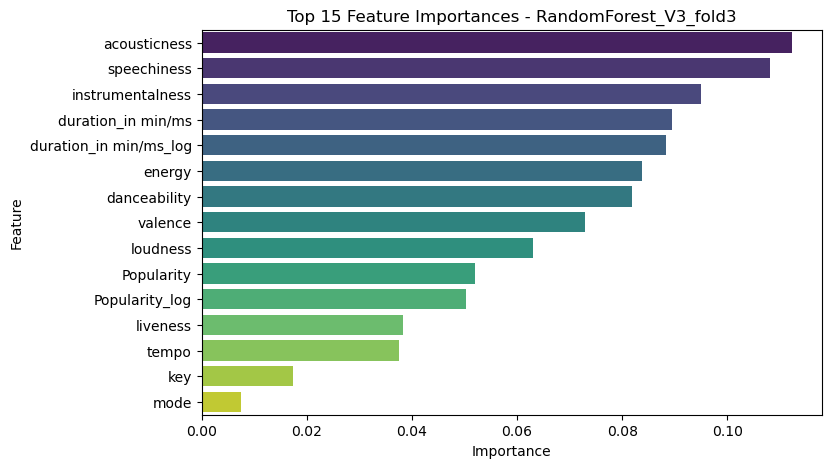

[I 2025-11-21 18:17:43,060] A new study created in memory with name: no-name-9c607cea-f1f9-48db-a9f0-acf951b8f997


💾 Model đã được lưu tại: experiments/models\RandomForest_V3_fold3_best.pkl

🔄 Fold 4/5
🔍 Đang tìm tham số tốt nhất cho Random Forest bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-21 18:17:46,497] Trial 0 finished with value: 0.493247698307095 and parameters: {'n_estimators': 400, 'max_depth': 6, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_samples': 0.8887561105939001}. Best is trial 0 with value: 0.493247698307095.
[I 2025-11-21 18:17:59,326] Trial 1 finished with value: 0.5547875072205938 and parameters: {'n_estimators': 500, 'max_depth': 18, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_samples': 0.8311040698287646}. Best is trial 1 with value: 0.5547875072205938.
[I 2025-11-21 18:18:01,421] Trial 2 finished with value: 0.472479080094174 and parameters: {'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2', 'max_samples': 0.9158075975927173}. Best is trial 1 with value: 0.5547875072205938.
[I 2025-11-21 18:18:10,023] Trial 3 finished with value: 0.5503857668818455 and parameters: {'n_estimators': 300, 'max_depth': 12, 'min_samples_split

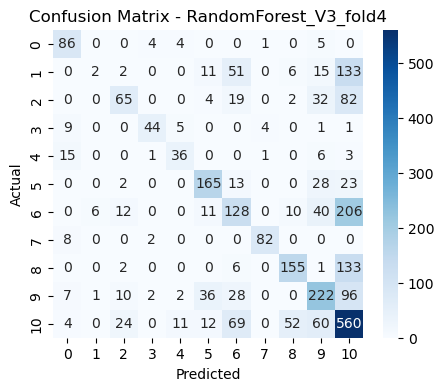

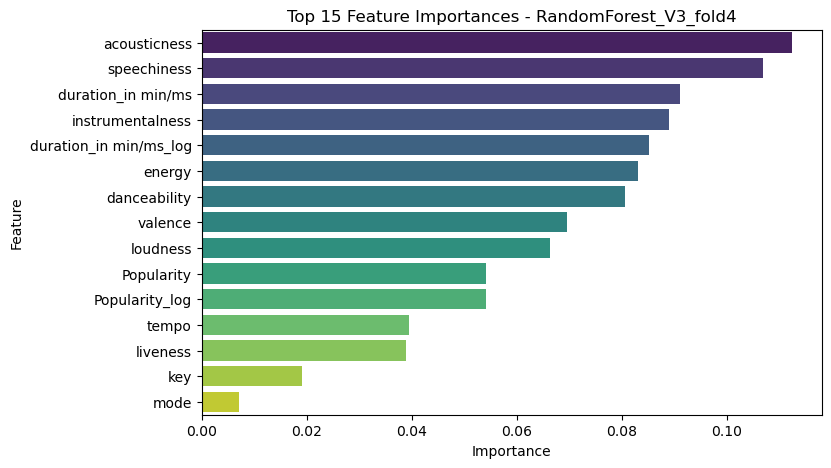

💾 Model đã được lưu tại: experiments/models\RandomForest_V3_fold4_best.pkl


[I 2025-11-21 18:19:41,999] A new study created in memory with name: no-name-7b6b171e-f341-4d89-803b-0bc0cc443a01



🔄 Fold 5/5
🔍 Đang tìm tham số tốt nhất cho Random Forest bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-21 18:19:46,318] Trial 0 finished with value: 0.5140426669942868 and parameters: {'n_estimators': 500, 'max_depth': 7, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_samples': 0.7164243991229172}. Best is trial 0 with value: 0.5140426669942868.
[I 2025-11-21 18:19:53,899] Trial 1 finished with value: 0.5495956572922157 and parameters: {'n_estimators': 300, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_samples': 0.8244611910606472}. Best is trial 1 with value: 0.5495956572922157.
[I 2025-11-21 18:19:59,032] Trial 2 finished with value: 0.5601799466496882 and parameters: {'n_estimators': 400, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_samples': 0.7018109569784619}. Best is trial 2 with value: 0.5601799466496882.
[I 2025-11-21 18:20:14,345] Trial 3 finished with value: 0.5592317545067149 and parameters: {'n_estimators': 400, 'max_depth': 18, 'min_samples_spl

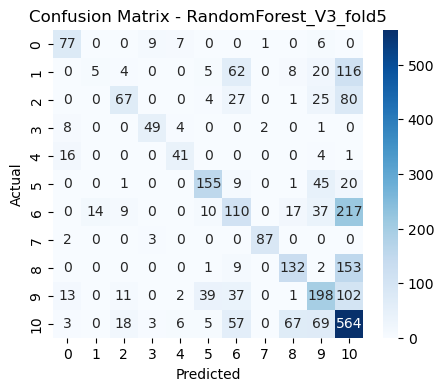

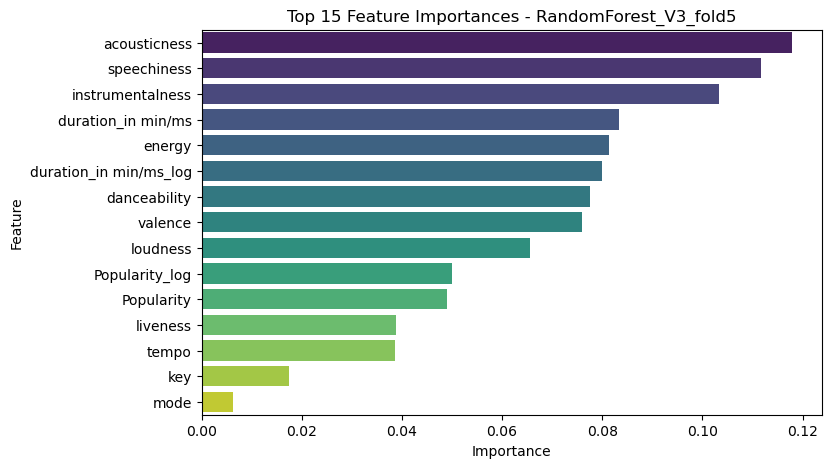

💾 Model đã được lưu tại: experiments/models\RandomForest_V3_fold5_best.pkl

📊 Average CV Metrics: {'Accuracy': 0.5258409796997414, 'Precision_macro': 0.5894766753870602, 'Recall_macro': 0.5583272701990968, 'F1_macro': 0.5595416897446274, 'ROC_AUC_ovr_macro': 0.8938280668172037}
RandomForest CV F1-Macro: 0.5595

==================== Training LightGBM ====================

🚀 Start CV run: LightGBM_V3_classification_CV_182139 (CV=5)

🔄 Fold 1/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[73]	valid_0's multi_logloss: 1.2008

🔹 Evaluation Report for LightGBM_V3_fold1 (classification)
              precision    recall  f1-score   support

           0       0.67      0.80      0.73       100
           1       0.13      0.02      0.04       219
           2       0.49      0.42      0.46       203
           3       0.84      0.71      0.77        65
           4       0.57      0.63      0.60        62
           5       0.70      0.72   

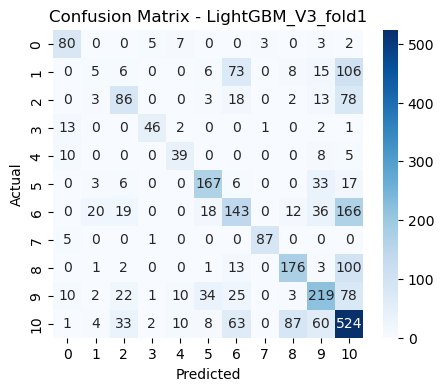

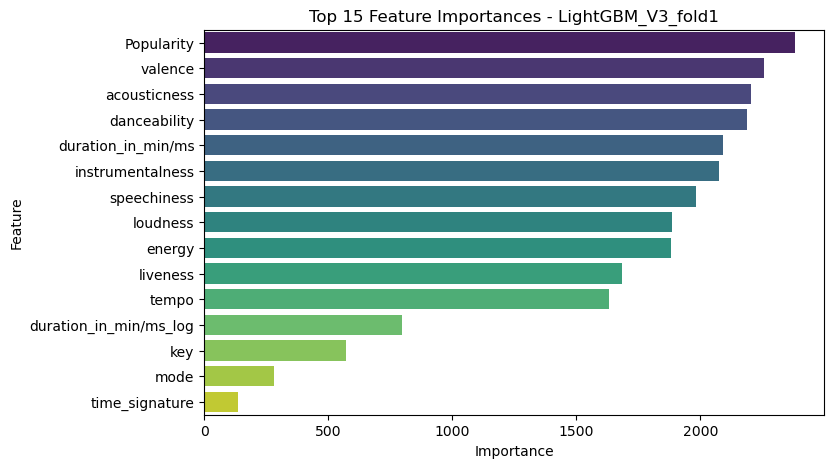


🔄 Fold 2/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[83]	valid_0's multi_logloss: 1.21645

🔹 Evaluation Report for LightGBM_V3_fold2 (classification)
              precision    recall  f1-score   support

           0       0.70      0.66      0.68       100
           1       0.28      0.04      0.06       219
           2       0.53      0.43      0.47       203
           3       0.75      0.69      0.72        65
           4       0.70      0.63      0.66        62
           5       0.64      0.74      0.69       232
           6       0.47      0.37      0.42       414
           7       0.92      0.92      0.92        92
           8       0.62      0.54      0.58       296
           9       0.54      0.54      0.54       404
          10       0.49      0.69      0.57       792

    accuracy                           0.55      2879
   macro avg       0.60      0.57      0.57      2879
weighted avg       0.54      0.55   

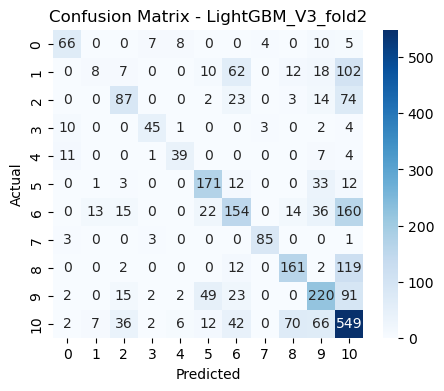

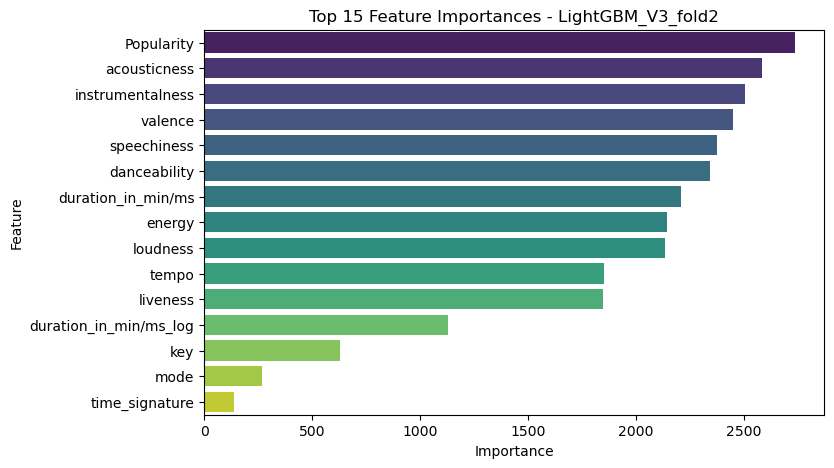


🔄 Fold 3/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[83]	valid_0's multi_logloss: 1.20794

🔹 Evaluation Report for LightGBM_V3_fold3 (classification)
              precision    recall  f1-score   support

           0       0.69      0.77      0.73       100
           1       0.17      0.03      0.05       220
           2       0.54      0.42      0.47       204
           3       0.82      0.72      0.77        64
           4       0.61      0.65      0.62        62
           5       0.71      0.75      0.73       231
           6       0.40      0.32      0.36       414
           7       0.92      0.93      0.93        92
           8       0.63      0.56      0.59       297
           9       0.55      0.52      0.54       404
          10       0.48      0.69      0.57       791

    accuracy                           0.55      2879
   macro avg       0.59      0.58      0.58      2879
weighted avg       0.52      0.55   

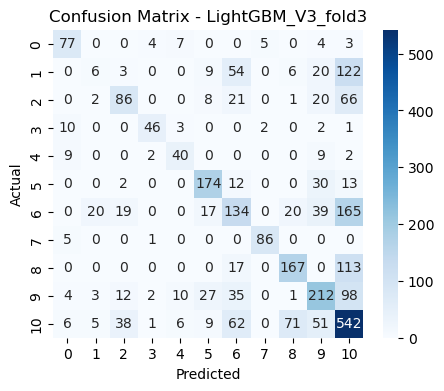

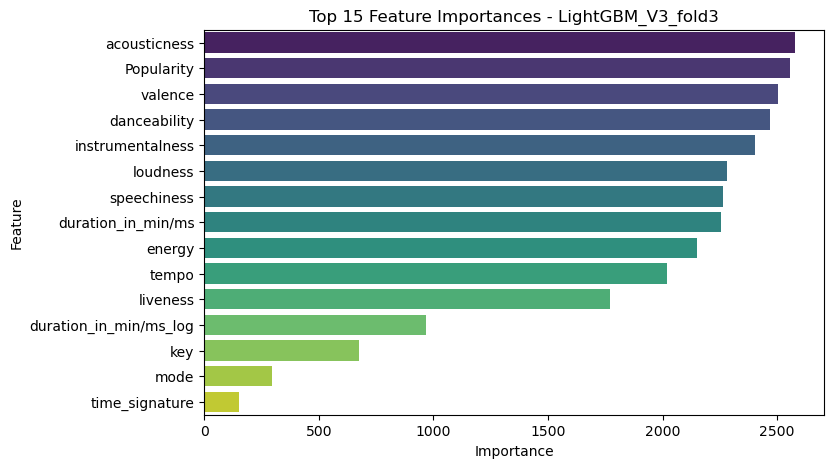


🔄 Fold 4/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[76]	valid_0's multi_logloss: 1.21614

🔹 Evaluation Report for LightGBM_V3_fold4 (classification)
              precision    recall  f1-score   support

           0       0.69      0.85      0.76       100
           1       0.07      0.01      0.02       220
           2       0.45      0.38      0.41       204
           3       0.88      0.72      0.79        64
           4       0.69      0.50      0.58        62
           5       0.70      0.72      0.71       231
           6       0.40      0.31      0.35       413
           7       0.92      0.91      0.92        92
           8       0.66      0.57      0.61       297
           9       0.56      0.57      0.56       404
          10       0.47      0.68      0.56       792

    accuracy                           0.54      2879
   macro avg       0.59      0.57      0.57      2879
weighted avg       0.52      0.54   

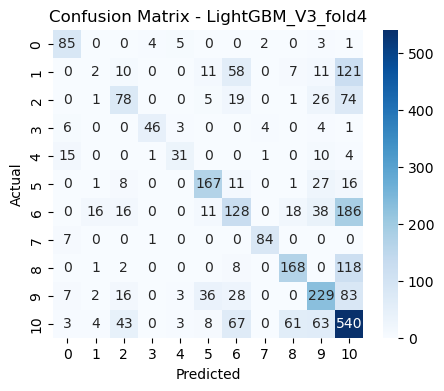

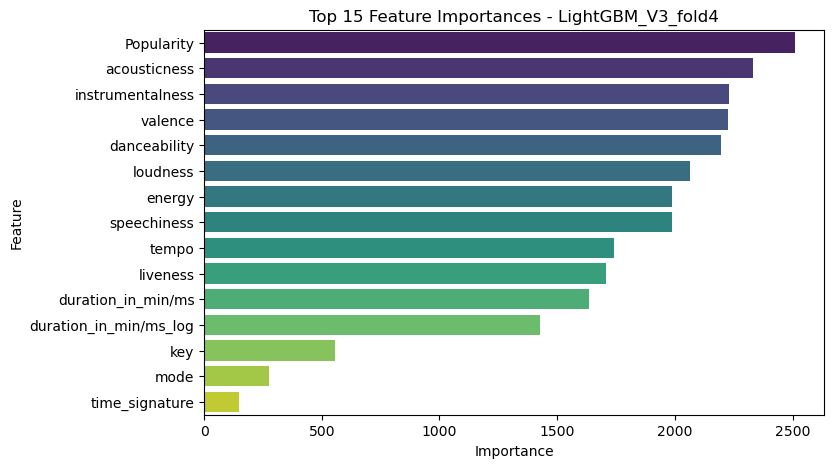


🔄 Fold 5/5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[89]	valid_0's multi_logloss: 1.2181

🔹 Evaluation Report for LightGBM_V3_fold5 (classification)
              precision    recall  f1-score   support

           0       0.71      0.80      0.75       100
           1       0.09      0.01      0.02       220
           2       0.54      0.44      0.48       204
           3       0.89      0.80      0.84        64
           4       0.71      0.63      0.67        62
           5       0.70      0.71      0.71       231
           6       0.36      0.28      0.32       414
           7       0.96      0.97      0.96        92
           8       0.55      0.49      0.52       297
           9       0.53      0.54      0.53       403
          10       0.46      0.66      0.54       792

    accuracy                           0.53      2879
   macro avg       0.59      0.57      0.58      2879
weighted avg       0.50      0.53    

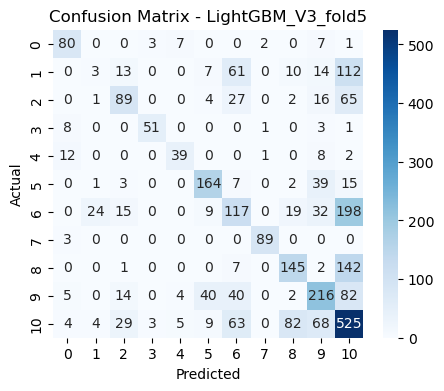

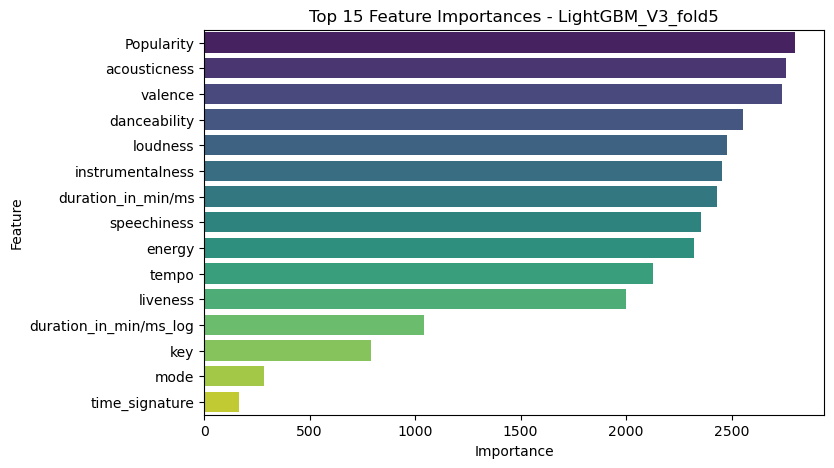


📊 Average CV Metrics: {'Accuracy': 0.5420252981359267, 'Precision_macro': 0.5931650843110743, 'Recall_macro': 0.5736952758334413, 'F1_macro': 0.5753709194885479, 'ROC_AUC_ovr_macro': 0.9015225895774404}
LightGBM CV F1-Macro: 0.5754

==================== Training XGBoost ====================

🚀 Start CV run: XGBoost_V3_classification_CV_182152 (CV=5)

🔄 Fold 1/5

🔹 Evaluation Report for XGBoost_V3_fold1 (classification)
              precision    recall  f1-score   support

           0       0.69      0.81      0.75       100
           1       0.07      0.03      0.04       219
           2       0.45      0.44      0.44       203
           3       0.82      0.72      0.77        65
           4       0.59      0.69      0.64        62
           5       0.73      0.69      0.71       232
           6       0.34      0.28      0.31       414
           7       0.95      0.95      0.95        93
           8       0.57      0.57      0.57       296
           9       0.53      0.53  

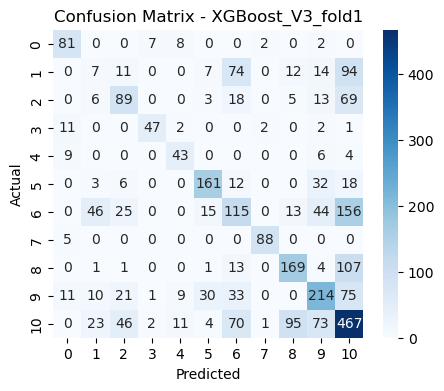

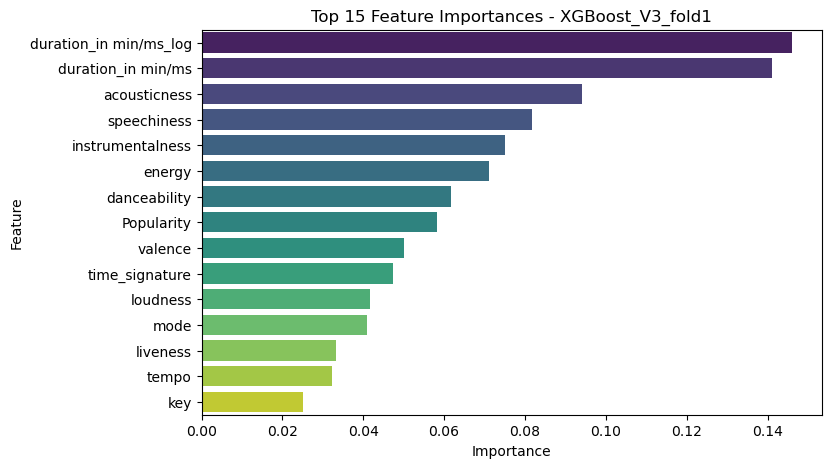


🔄 Fold 2/5

🔹 Evaluation Report for XGBoost_V3_fold2 (classification)
              precision    recall  f1-score   support

           0       0.71      0.67      0.69       100
           1       0.13      0.04      0.06       219
           2       0.52      0.40      0.45       203
           3       0.75      0.71      0.73        65
           4       0.69      0.73      0.71        62
           5       0.68      0.74      0.71       232
           6       0.39      0.33      0.36       414
           7       0.95      0.93      0.94        92
           8       0.61      0.50      0.55       296
           9       0.56      0.56      0.56       404
          10       0.47      0.65      0.55       792

    accuracy                           0.53      2879
   macro avg       0.59      0.57      0.57      2879
weighted avg       0.52      0.53      0.52      2879


 Tổng hợp metrics:
                   XGBoost_V3_fold2
Accuracy                   0.532824
Precision_macro         

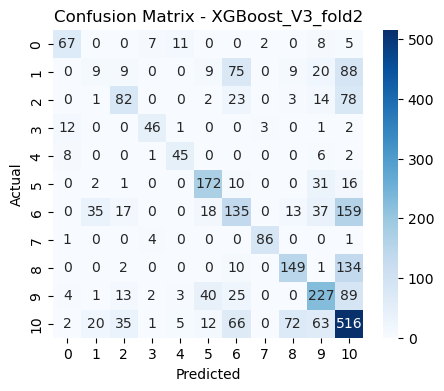

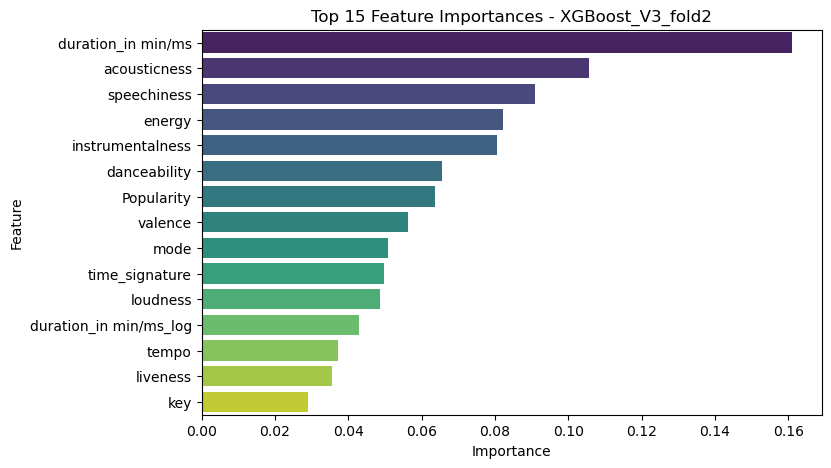


🔄 Fold 3/5

🔹 Evaluation Report for XGBoost_V3_fold3 (classification)
              precision    recall  f1-score   support

           0       0.68      0.77      0.72       100
           1       0.11      0.04      0.06       220
           2       0.53      0.41      0.46       204
           3       0.81      0.75      0.78        64
           4       0.65      0.65      0.65        62
           5       0.74      0.74      0.74       231
           6       0.35      0.32      0.34       414
           7       0.92      0.93      0.93        92
           8       0.61      0.55      0.58       297
           9       0.57      0.55      0.56       404
          10       0.47      0.62      0.53       791

    accuracy                           0.53      2879
   macro avg       0.59      0.58      0.58      2879
weighted avg       0.51      0.53      0.52      2879


 Tổng hợp metrics:
                   XGBoost_V3_fold3
Accuracy                   0.529350
Precision_macro         

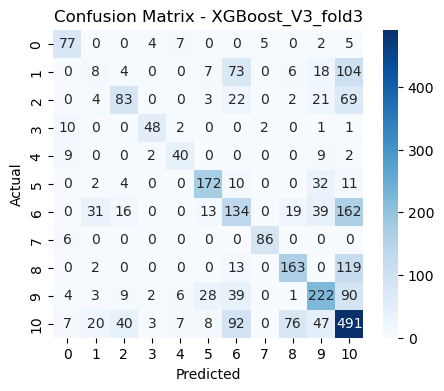

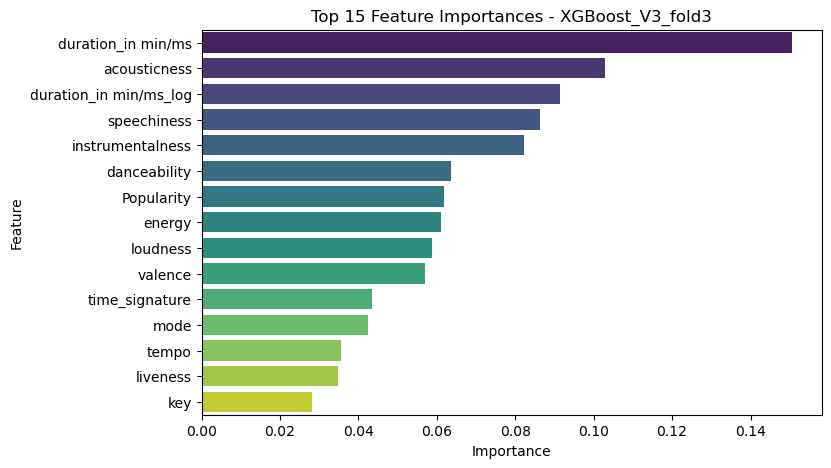


🔄 Fold 4/5

🔹 Evaluation Report for XGBoost_V3_fold4 (classification)
              precision    recall  f1-score   support

           0       0.69      0.82      0.75       100
           1       0.10      0.03      0.05       220
           2       0.50      0.40      0.44       204
           3       0.85      0.70      0.77        64
           4       0.69      0.60      0.64        62
           5       0.70      0.70      0.70       231
           6       0.38      0.34      0.36       413
           7       0.89      0.90      0.90        92
           8       0.63      0.53      0.57       297
           9       0.55      0.56      0.56       404
          10       0.46      0.62      0.53       792

    accuracy                           0.53      2879
   macro avg       0.59      0.56      0.57      2879
weighted avg       0.51      0.53      0.51      2879


 Tổng hợp metrics:
                   XGBoost_V3_fold4
Accuracy                   0.525877
Precision_macro         

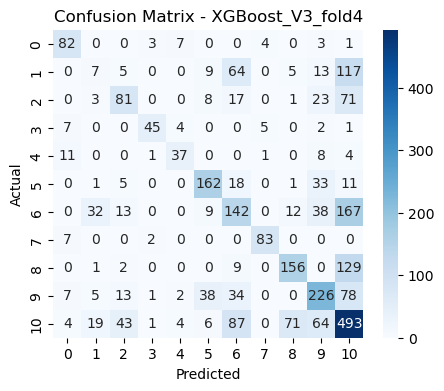

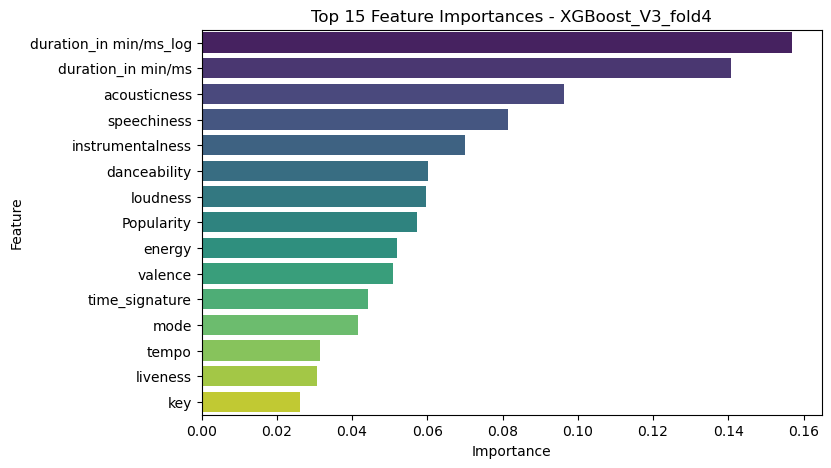


🔄 Fold 5/5

🔹 Evaluation Report for XGBoost_V3_fold5 (classification)
              precision    recall  f1-score   support

           0       0.69      0.77      0.73       100
           1       0.04      0.01      0.02       220
           2       0.58      0.45      0.51       204
           3       0.83      0.84      0.84        64
           4       0.66      0.65      0.65        62
           5       0.71      0.69      0.70       231
           6       0.36      0.31      0.33       414
           7       0.97      0.92      0.94        92
           8       0.58      0.49      0.53       297
           9       0.50      0.51      0.51       403
          10       0.46      0.63      0.53       792

    accuracy                           0.52      2879
   macro avg       0.58      0.57      0.57      2879
weighted avg       0.50      0.52      0.50      2879


 Tổng hợp metrics:
                   XGBoost_V3_fold5
Accuracy                   0.516151
Precision_macro         

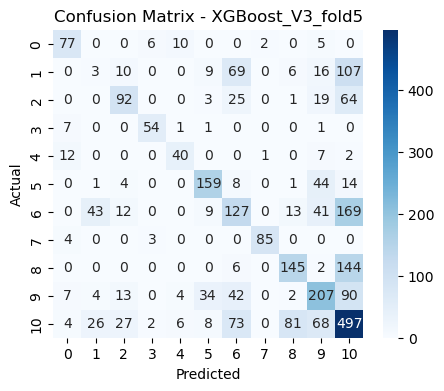

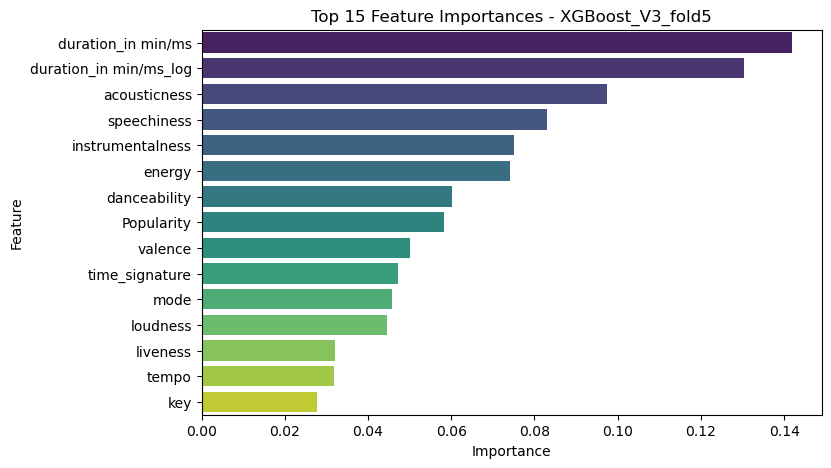


📊 Average CV Metrics: {'Accuracy': 0.5236877918644591, 'Precision_macro': 0.5812394290472013, 'Recall_macro': 0.570517258193516, 'F1_macro': 0.5717382050161827, 'ROC_AUC_ovr_macro': 0.895596726915552}
XGBoost CV F1-Macro: 0.5717

==================== Training CatBoost ====================

🚀 Start CV run: CatBoost_V3_classification_CV_182219 (CV=5)

🔄 Fold 1/5
0:	learn: 2.3001106	test: 2.3011574	best: 2.3011574 (0)	total: 162ms	remaining: 1m 20s
100:	learn: 1.2233985	test: 1.2698783	best: 1.2698783 (100)	total: 1.58s	remaining: 6.25s
200:	learn: 1.1148116	test: 1.2130963	best: 1.2130963 (200)	total: 2.97s	remaining: 4.42s
300:	learn: 1.0444175	test: 1.1907126	best: 1.1907126 (300)	total: 4.32s	remaining: 2.86s
400:	learn: 0.9897558	test: 1.1819523	best: 1.1819523 (400)	total: 5.79s	remaining: 1.43s
499:	learn: 0.9433564	test: 1.1798465	best: 1.1798465 (499)	total: 7.18s	remaining: 0us

bestTest = 1.1798465
bestIteration = 499


🔹 Evaluation Report for CatBoost_V3_fold1 (classification

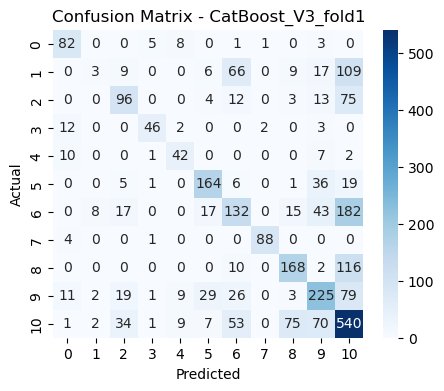

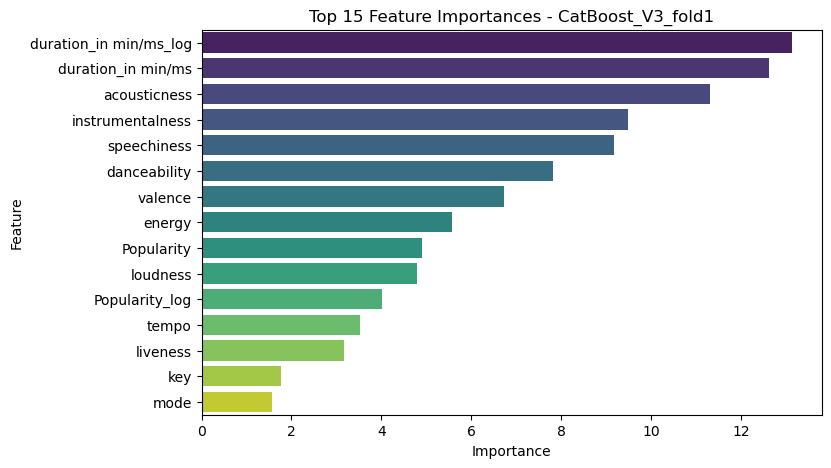


🔄 Fold 2/5
0:	learn: 2.2987274	test: 2.2996754	best: 2.2996754 (0)	total: 15.5ms	remaining: 7.72s
100:	learn: 1.2226528	test: 1.2810046	best: 1.2810046 (100)	total: 1.43s	remaining: 5.67s
200:	learn: 1.1127374	test: 1.2232040	best: 1.2232040 (200)	total: 2.81s	remaining: 4.18s
300:	learn: 1.0440188	test: 1.1986717	best: 1.1986717 (300)	total: 4.22s	remaining: 2.79s
400:	learn: 0.9897762	test: 1.1884248	best: 1.1884248 (400)	total: 5.63s	remaining: 1.39s
499:	learn: 0.9432673	test: 1.1850837	best: 1.1850837 (499)	total: 7.11s	remaining: 0us

bestTest = 1.185083652
bestIteration = 499


🔹 Evaluation Report for CatBoost_V3_fold2 (classification)
              precision    recall  f1-score   support

           0       0.65      0.68      0.67       100
           1       0.50      0.01      0.02       219
           2       0.54      0.45      0.49       203
           3       0.78      0.77      0.78        65
           4       0.64      0.63      0.63        62
           5       0.64

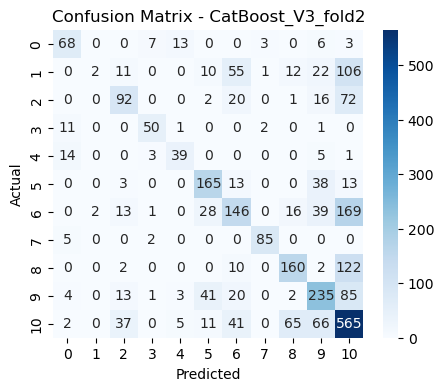

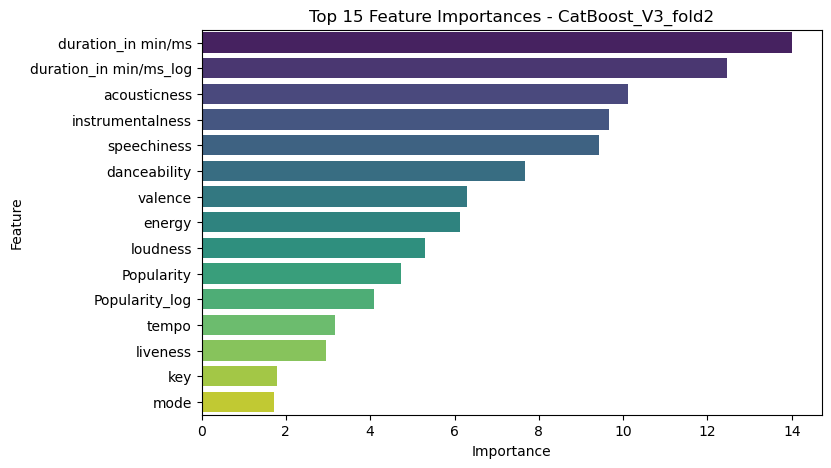


🔄 Fold 3/5
0:	learn: 2.3006852	test: 2.3030358	best: 2.3030358 (0)	total: 15.4ms	remaining: 7.66s
100:	learn: 1.2215324	test: 1.2805795	best: 1.2805795 (100)	total: 1.52s	remaining: 5.99s
200:	learn: 1.1091959	test: 1.2216000	best: 1.2216000 (200)	total: 2.96s	remaining: 4.41s
300:	learn: 1.0400856	test: 1.2004542	best: 1.2004542 (300)	total: 4.4s	remaining: 2.91s
400:	learn: 0.9834213	test: 1.1919642	best: 1.1919642 (400)	total: 5.9s	remaining: 1.46s
499:	learn: 0.9387260	test: 1.1898535	best: 1.1897355 (497)	total: 7.25s	remaining: 0us

bestTest = 1.189735462
bestIteration = 497

Shrink model to first 498 iterations.

🔹 Evaluation Report for CatBoost_V3_fold3 (classification)
              precision    recall  f1-score   support

           0       0.64      0.74      0.69       100
           1       0.45      0.02      0.04       220
           2       0.52      0.43      0.47       204
           3       0.75      0.64      0.69        64
           4       0.58      0.63      0.

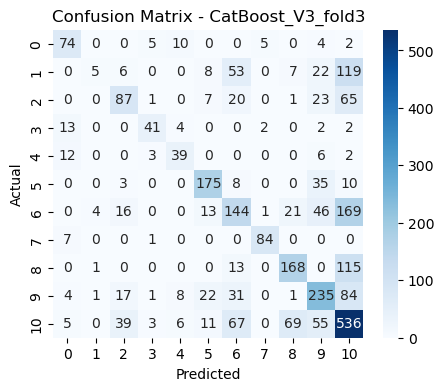

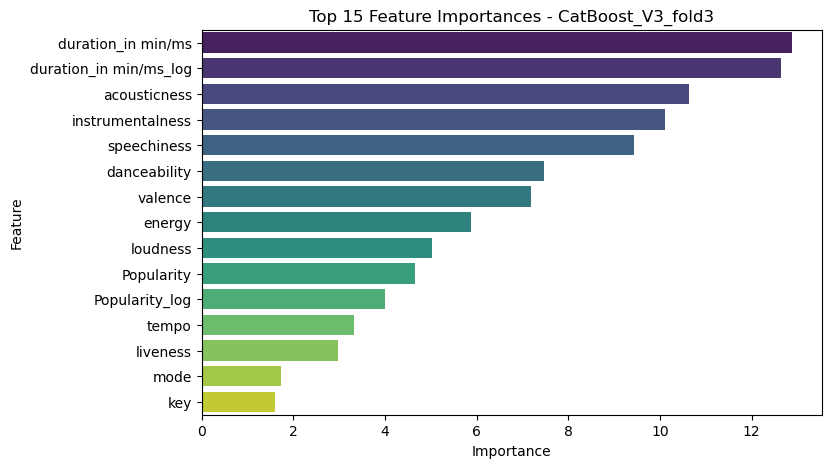


🔄 Fold 4/5
0:	learn: 2.2983709	test: 2.3000123	best: 2.3000123 (0)	total: 15.8ms	remaining: 7.88s
100:	learn: 1.2220957	test: 1.2769555	best: 1.2769555 (100)	total: 1.45s	remaining: 5.71s
200:	learn: 1.1133896	test: 1.2197008	best: 1.2197008 (200)	total: 2.85s	remaining: 4.24s
300:	learn: 1.0443918	test: 1.1975049	best: 1.1975049 (300)	total: 4.2s	remaining: 2.78s
400:	learn: 0.9891091	test: 1.1877955	best: 1.1877955 (400)	total: 5.59s	remaining: 1.38s
499:	learn: 0.9435281	test: 1.1837760	best: 1.1836445 (494)	total: 6.96s	remaining: 0us

bestTest = 1.18364448
bestIteration = 494

Shrink model to first 495 iterations.

🔹 Evaluation Report for CatBoost_V3_fold4 (classification)
              precision    recall  f1-score   support

           0       0.69      0.84      0.76       100
           1       0.27      0.01      0.03       220
           2       0.46      0.38      0.41       204
           3       0.76      0.75      0.76        64
           4       0.70      0.56      0.

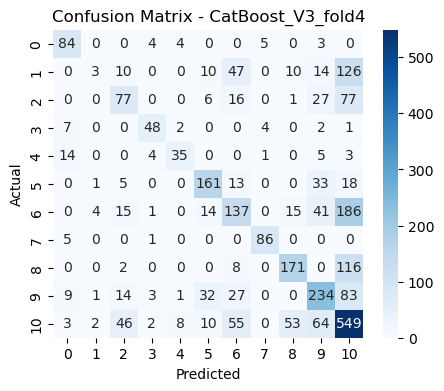

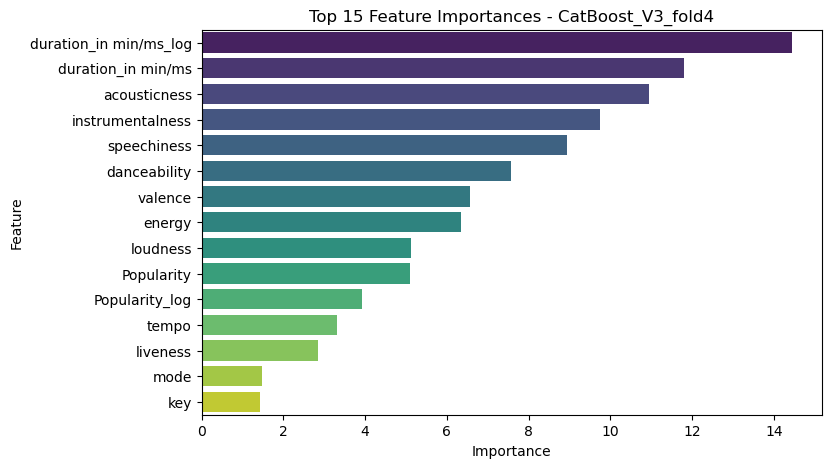


🔄 Fold 5/5
0:	learn: 2.3055568	test: 2.3072359	best: 2.3072359 (0)	total: 15.8ms	remaining: 7.89s
100:	learn: 1.2198971	test: 1.2985746	best: 1.2985746 (100)	total: 1.39s	remaining: 5.5s
200:	learn: 1.1084442	test: 1.2392406	best: 1.2392406 (200)	total: 2.75s	remaining: 4.09s
300:	learn: 1.0388756	test: 1.2162529	best: 1.2160826 (299)	total: 4.14s	remaining: 2.74s
400:	learn: 0.9839360	test: 1.2054003	best: 1.2054003 (400)	total: 5.48s	remaining: 1.35s
499:	learn: 0.9387159	test: 1.2002255	best: 1.2000768 (497)	total: 6.9s	remaining: 0us

bestTest = 1.200076819
bestIteration = 497

Shrink model to first 498 iterations.

🔹 Evaluation Report for CatBoost_V3_fold5 (classification)
              precision    recall  f1-score   support

           0       0.67      0.74      0.70       100
           1       0.36      0.02      0.04       220
           2       0.59      0.44      0.50       204
           3       0.80      0.80      0.80        64
           4       0.69      0.68      0.

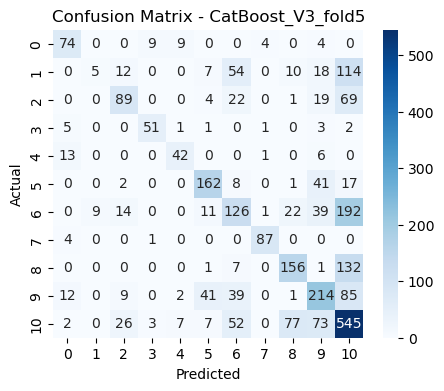

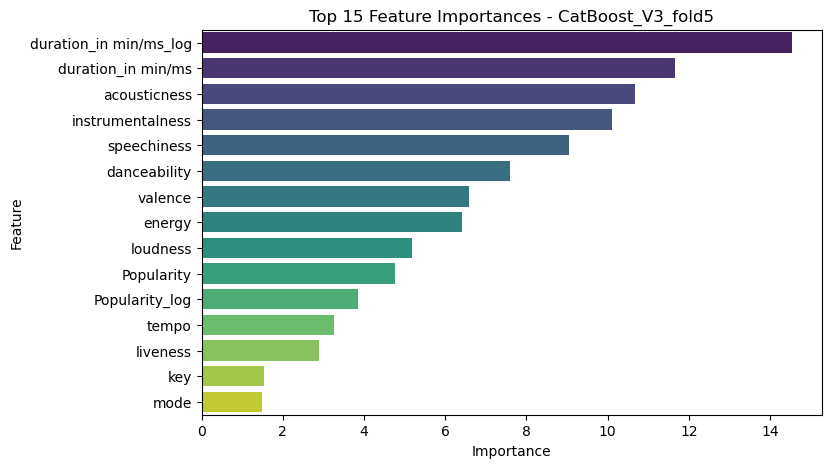


📊 Average CV Metrics: {'Accuracy': 0.5499443769055613, 'Precision_macro': 0.6079760947719697, 'Recall_macro': 0.5793176444658938, 'F1_macro': 0.5756767398746749, 'ROC_AUC_ovr_macro': 0.9056672775604694}
CatBoost CV F1-Macro: 0.5757

==================== Training SVM ====================

🚀 Start CV run: SVM_V3_classification_CV_182257 (CV=5)

🔄 Fold 1/5
🔍 Đang tìm tham số tốt nhất cho SVM...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
✅ Best params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
🚀 Huấn luyện mô hình SVM...

🔹 Evaluation Report for SVM_V3_fold1 (classification)
              precision    recall  f1-score   support

           0       0.63      0.78      0.70       100
           1       0.18      0.03      0.05       219
           2       0.44      0.36      0.40       203
           3       0.80      0.60      0.68        65
           4       0.60      0.66      0.63        62
           5       0.69      0.67      0.68       232
           6       0.3

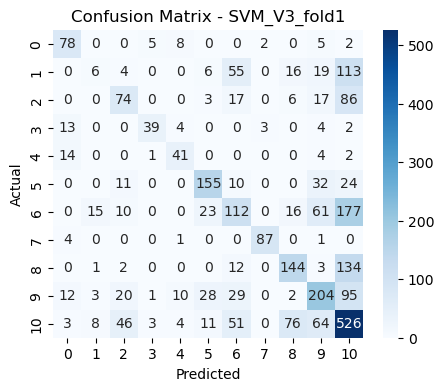

⚠️ Mô hình không có thông tin feature importance.
💾 Model đã được lưu tại: experiments/models\SVM_V3_fold1_best.pkl

🔄 Fold 2/5
🔍 Đang tìm tham số tốt nhất cho SVM...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
✅ Best params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
🚀 Huấn luyện mô hình SVM...

🔹 Evaluation Report for SVM_V3_fold2 (classification)
              precision    recall  f1-score   support

           0       0.64      0.67      0.65       100
           1       0.31      0.04      0.07       219
           2       0.51      0.36      0.43       203
           3       0.80      0.75      0.78        65
           4       0.61      0.60      0.60        62
           5       0.61      0.67      0.64       232
           6       0.39      0.28      0.33       414
           7       0.94      0.91      0.93        92
           8       0.61      0.45      0.51       296
           9       0.49      0.52      0.51       404
          10       0.46      0.70  

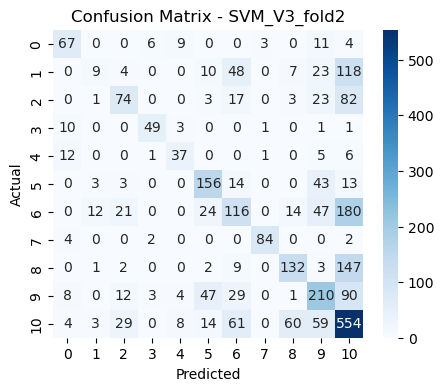

⚠️ Mô hình không có thông tin feature importance.
💾 Model đã được lưu tại: experiments/models\SVM_V3_fold2_best.pkl

🔄 Fold 3/5
🔍 Đang tìm tham số tốt nhất cho SVM...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
✅ Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
🚀 Huấn luyện mô hình SVM...

🔹 Evaluation Report for SVM_V3_fold3 (classification)
              precision    recall  f1-score   support

           0       0.69      0.79      0.74       100
           1       0.16      0.02      0.04       220
           2       0.48      0.39      0.43       204
           3       0.72      0.69      0.70        64
           4       0.61      0.68      0.64        62
           5       0.69      0.70      0.70       231
           6       0.37      0.26      0.31       414
           7       0.92      0.88      0.90        92
           8       0.59      0.52      0.55       297
           9       0.53      0.54      0.54       404
          10       0.46      0.67 

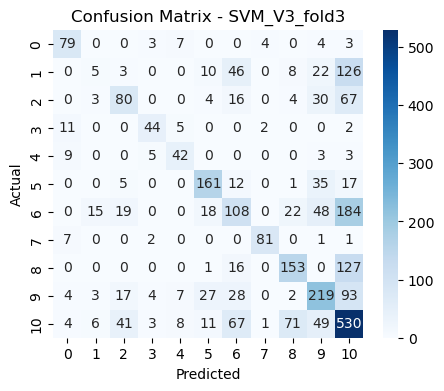

⚠️ Mô hình không có thông tin feature importance.
💾 Model đã được lưu tại: experiments/models\SVM_V3_fold3_best.pkl

🔄 Fold 4/5
🔍 Đang tìm tham số tốt nhất cho SVM...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
✅ Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
🚀 Huấn luyện mô hình SVM...

🔹 Evaluation Report for SVM_V3_fold4 (classification)
              precision    recall  f1-score   support

           0       0.63      0.81      0.71       100
           1       0.12      0.02      0.03       220
           2       0.46      0.37      0.41       204
           3       0.78      0.72      0.75        64
           4       0.62      0.58      0.60        62
           5       0.68      0.71      0.70       231
           6       0.42      0.28      0.34       413
           7       0.91      0.86      0.88        92
           8       0.66      0.49      0.56       297
           9       0.52      0.52      0.52       404
          10       0.46      0.70 

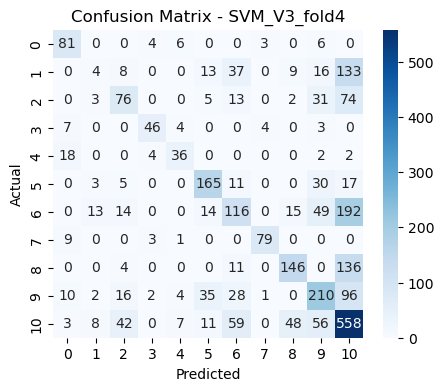

⚠️ Mô hình không có thông tin feature importance.
💾 Model đã được lưu tại: experiments/models\SVM_V3_fold4_best.pkl

🔄 Fold 5/5
🔍 Đang tìm tham số tốt nhất cho SVM...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
✅ Best params: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
🚀 Huấn luyện mô hình SVM...

🔹 Evaluation Report for SVM_V3_fold5 (classification)
              precision    recall  f1-score   support

           0       0.62      0.79      0.70       100
           1       0.44      0.02      0.03       220
           2       0.60      0.31      0.41       204
           3       0.85      0.69      0.76        64
           4       0.49      0.58      0.53        62
           5       0.67      0.68      0.67       231
           6       0.44      0.24      0.31       414
           7       0.97      0.92      0.94        92
           8       0.59      0.40      0.47       297
           9       0.49      0.48      0.48       403
          10       0.44      0.76   

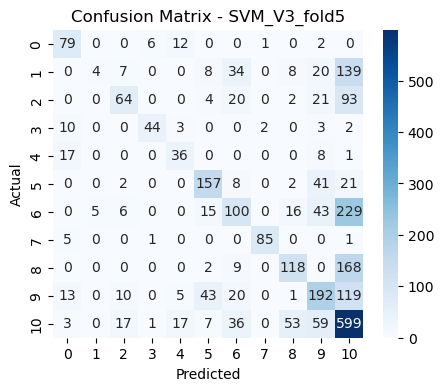

⚠️ Mô hình không có thông tin feature importance.
💾 Model đã được lưu tại: experiments/models\SVM_V3_fold5_best.pkl

📊 Average CV Metrics: {'Accuracy': 0.5175749199181815, 'Precision_macro': 0.5755446580604993, 'Recall_macro': 0.5452822712953337, 'F1_macro': 0.5451731063505612, 'ROC_AUC_ovr_macro': 0.8946258997357421}
SVM CV F1-Macro: 0.5452

==================== Training KNN ====================

🚀 Start CV run: KNN_V3_classification_CV_183234 (CV=5)

🔄 Fold 1/5
🔍 Đang tìm số láng giềng tối ưu (k)...
✅ K tốt nhất: 16

🔹 Evaluation Report for KNN_V3_fold1 (classification)
              precision    recall  f1-score   support

           0       0.64      0.81      0.71       100
           1       0.25      0.07      0.11       219
           2       0.45      0.33      0.38       203
           3       0.81      0.65      0.72        65
           4       0.55      0.66      0.60        62
           5       0.68      0.67      0.68       232
           6       0.33      0.24      0.2

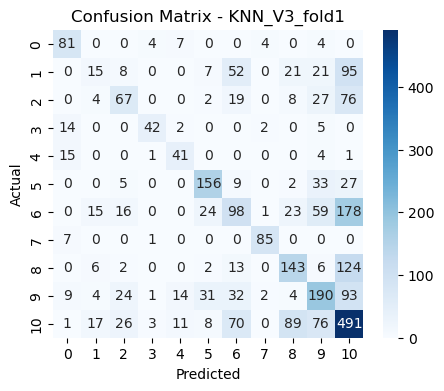

⚠️ Mô hình không có thông tin feature importance.
💾 Mô hình KNN đã lưu tại: experiments/models\KNN_V3_fold1_best.pkl

🔄 Fold 2/5
🔍 Đang tìm số láng giềng tối ưu (k)...
✅ K tốt nhất: 19

🔹 Evaluation Report for KNN_V3_fold2 (classification)
              precision    recall  f1-score   support

           0       0.62      0.72      0.66       100
           1       0.23      0.05      0.08       219
           2       0.45      0.32      0.37       203
           3       0.76      0.63      0.69        65
           4       0.52      0.63      0.57        62
           5       0.64      0.65      0.65       232
           6       0.38      0.26      0.31       414
           7       0.92      0.90      0.91        92
           8       0.48      0.44      0.46       296
           9       0.44      0.46      0.45       404
          10       0.43      0.63      0.51       792

    accuracy                           0.48      2879
   macro avg       0.53      0.52      0.52      2879
we

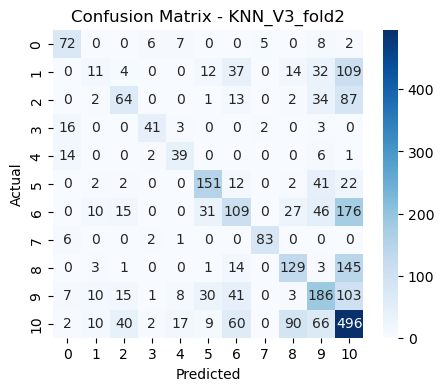

⚠️ Mô hình không có thông tin feature importance.
💾 Mô hình KNN đã lưu tại: experiments/models\KNN_V3_fold2_best.pkl

🔄 Fold 3/5
🔍 Đang tìm số láng giềng tối ưu (k)...
✅ K tốt nhất: 14

🔹 Evaluation Report for KNN_V3_fold3 (classification)
              precision    recall  f1-score   support

           0       0.58      0.76      0.66       100
           1       0.15      0.04      0.06       220
           2       0.39      0.33      0.36       204
           3       0.86      0.56      0.68        64
           4       0.45      0.65      0.53        62
           5       0.70      0.67      0.69       231
           6       0.32      0.22      0.26       414
           7       0.89      0.90      0.90        92
           8       0.50      0.51      0.50       297
           9       0.44      0.46      0.45       404
          10       0.44      0.60      0.51       791

    accuracy                           0.47      2879
   macro avg       0.52      0.52      0.51      2879
we

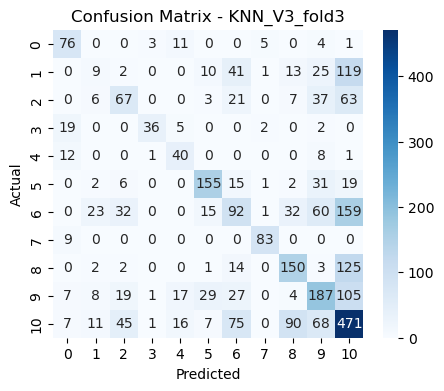

⚠️ Mô hình không có thông tin feature importance.
💾 Mô hình KNN đã lưu tại: experiments/models\KNN_V3_fold3_best.pkl

🔄 Fold 4/5
🔍 Đang tìm số láng giềng tối ưu (k)...
✅ K tốt nhất: 17

🔹 Evaluation Report for KNN_V3_fold4 (classification)
              precision    recall  f1-score   support

           0       0.58      0.78      0.66       100
           1       0.08      0.02      0.03       220
           2       0.41      0.32      0.36       204
           3       0.79      0.58      0.67        64
           4       0.51      0.60      0.55        62
           5       0.70      0.68      0.69       231
           6       0.37      0.27      0.31       413
           7       0.89      0.90      0.90        92
           8       0.54      0.43      0.48       297
           9       0.47      0.48      0.47       404
          10       0.44      0.64      0.52       792

    accuracy                           0.49      2879
   macro avg       0.53      0.52      0.51      2879
we

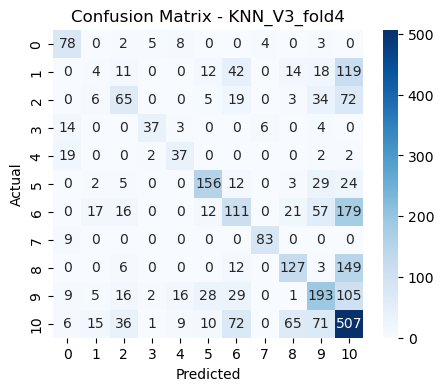

⚠️ Mô hình không có thông tin feature importance.
💾 Mô hình KNN đã lưu tại: experiments/models\KNN_V3_fold4_best.pkl

🔄 Fold 5/5
🔍 Đang tìm số láng giềng tối ưu (k)...
✅ K tốt nhất: 16

🔹 Evaluation Report for KNN_V3_fold5 (classification)
              precision    recall  f1-score   support

           0       0.59      0.72      0.65       100
           1       0.13      0.04      0.06       220
           2       0.46      0.35      0.40       204
           3       0.85      0.69      0.76        64
           4       0.45      0.61      0.52        62
           5       0.66      0.65      0.65       231
           6       0.36      0.27      0.31       414
           7       0.89      0.91      0.90        92
           8       0.52      0.46      0.49       297
           9       0.45      0.41      0.43       403
          10       0.44      0.63      0.52       792

    accuracy                           0.48      2879
   macro avg       0.53      0.52      0.52      2879
we

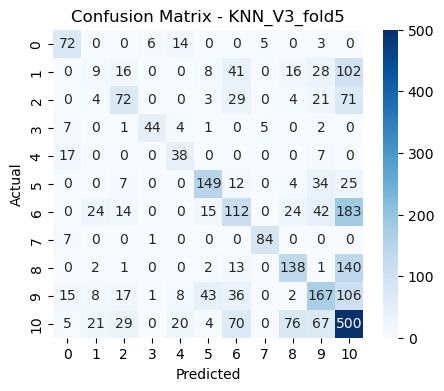

⚠️ Mô hình không có thông tin feature importance.
💾 Mô hình KNN đã lưu tại: experiments/models\KNN_V3_fold5_best.pkl

📊 Average CV Metrics: {'Accuracy': 0.48200838929412215, 'Precision_macro': 0.5308372992757402, 'Recall_macro': 0.5223447530621886, 'F1_macro': 0.5172604478611864, 'ROC_AUC_ovr_macro': 0.8605960480775959}
KNN CV F1-Macro: 0.5173

==================== Training NaiveBayes ====================

🚀 Start CV run: NaiveBayes_V3_classification_CV_183245 (CV=5)

🔄 Fold 1/5
🚀 Huấn luyện mô hình Naive Bayes (gaussian)...

🔹 Evaluation Report for NaiveBayes_V3_fold1 (classification)
              precision    recall  f1-score   support

           0       0.62      0.69      0.65       100
           1       0.12      0.21      0.16       219
           2       0.32      0.41      0.36       203
           3       0.61      0.60      0.60        65
           4       0.39      0.94      0.55        62
           5       0.38      0.78      0.51       232
           6       0.31     

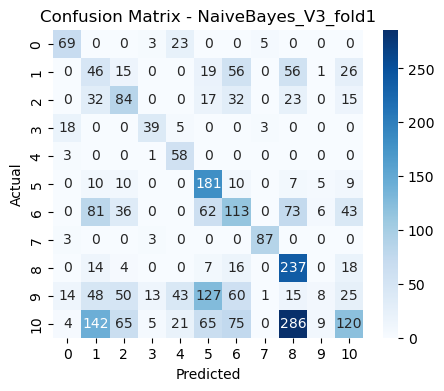

⚠️ Mô hình không có thông tin feature importance.
💾 Model Naive Bayes đã lưu tại: experiments/models\NaiveBayes_V3_fold1_gaussian_best.pkl

🔄 Fold 2/5
🚀 Huấn luyện mô hình Naive Bayes (gaussian)...

🔹 Evaluation Report for NaiveBayes_V3_fold2 (classification)
              precision    recall  f1-score   support

           0       0.54      0.52      0.53       100
           1       0.12      0.16      0.13       219
           2       0.33      0.48      0.39       203
           3       0.38      0.49      0.43        65
           4       0.37      0.81      0.51        62
           5       0.38      0.83      0.52       232
           6       0.34      0.29      0.31       414
           7       0.88      0.89      0.89        92
           8       0.34      0.81      0.48       296
           9       0.44      0.04      0.08       404
          10       0.51      0.19      0.27       792

    accuracy                           0.37      2879
   macro avg       0.42      0.50   

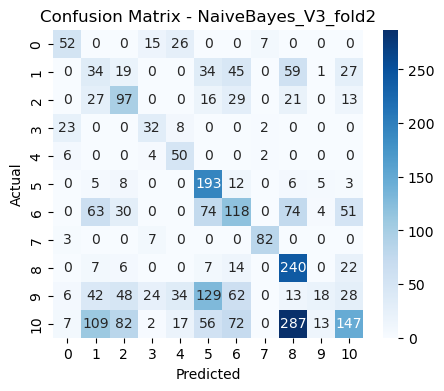

⚠️ Mô hình không có thông tin feature importance.
💾 Model Naive Bayes đã lưu tại: experiments/models\NaiveBayes_V3_fold2_gaussian_best.pkl

🔄 Fold 3/5
🚀 Huấn luyện mô hình Naive Bayes (gaussian)...

🔹 Evaluation Report for NaiveBayes_V3_fold3 (classification)
              precision    recall  f1-score   support

           0       0.51      0.56      0.54       100
           1       0.17      0.23      0.20       220
           2       0.29      0.46      0.36       204
           3       0.51      0.50      0.50        64
           4       0.34      0.84      0.48        62
           5       0.40      0.83      0.54       231
           6       0.30      0.24      0.26       414
           7       0.93      0.95      0.94        92
           8       0.36      0.83      0.50       297
           9       0.26      0.02      0.04       404
          10       0.51      0.20      0.29       791

    accuracy                           0.37      2879
   macro avg       0.42      0.51   

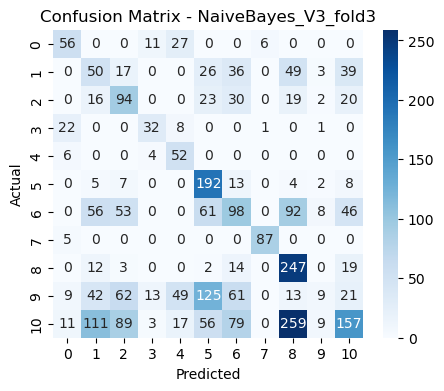

⚠️ Mô hình không có thông tin feature importance.
💾 Model Naive Bayes đã lưu tại: experiments/models\NaiveBayes_V3_fold3_gaussian_best.pkl

🔄 Fold 4/5
🚀 Huấn luyện mô hình Naive Bayes (gaussian)...

🔹 Evaluation Report for NaiveBayes_V3_fold4 (classification)
              precision    recall  f1-score   support

           0       0.53      0.63      0.58       100
           1       0.15      0.16      0.15       220
           2       0.28      0.48      0.36       204
           3       0.53      0.52      0.52        64
           4       0.40      0.84      0.54        62
           5       0.38      0.80      0.52       231
           6       0.36      0.29      0.32       413
           7       0.82      0.87      0.84        92
           8       0.36      0.80      0.50       297
           9       0.34      0.03      0.06       404
          10       0.46      0.21      0.29       792

    accuracy                           0.38      2879
   macro avg       0.42      0.51   

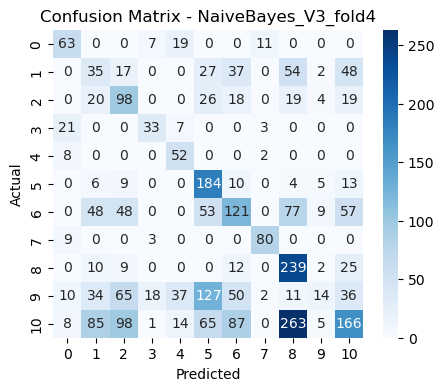

⚠️ Mô hình không có thông tin feature importance.
💾 Model Naive Bayes đã lưu tại: experiments/models\NaiveBayes_V3_fold4_gaussian_best.pkl

🔄 Fold 5/5
🚀 Huấn luyện mô hình Naive Bayes (gaussian)...

🔹 Evaluation Report for NaiveBayes_V3_fold5 (classification)
              precision    recall  f1-score   support

           0       0.54      0.46      0.50       100
           1       0.14      0.21      0.17       220
           2       0.33      0.50      0.40       204
           3       0.56      0.70      0.62        64
           4       0.34      0.84      0.49        62
           5       0.42      0.80      0.55       231
           6       0.32      0.27      0.30       414
           7       0.89      0.95      0.92        92
           8       0.34      0.77      0.47       297
           9       0.46      0.05      0.09       403
          10       0.50      0.20      0.29       792

    accuracy                           0.38      2879
   macro avg       0.44      0.52   

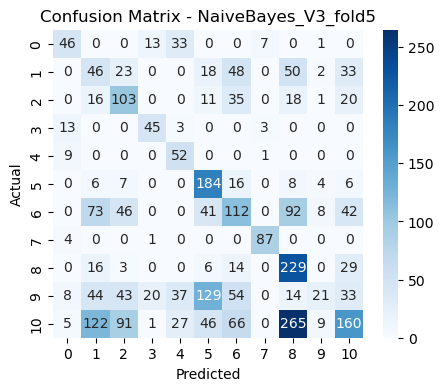

⚠️ Mô hình không có thông tin feature importance.
💾 Model Naive Bayes đã lưu tại: experiments/models\NaiveBayes_V3_fold5_gaussian_best.pkl

📊 Average CV Metrics: {'Accuracy': 0.3715622226081587, 'Precision_macro': 0.4252484668431519, 'Recall_macro': 0.5154409616085418, 'F1_macro': 0.4261590330718814, 'ROC_AUC_ovr_macro': 0.8552249869920558}
NaiveBayes CV F1-Macro: 0.4262


In [5]:
# Define Models
models = {
    "RandomForest": ModelRandomForest,
    "LightGBM": ModelLightGBM,
    "XGBoost": ModelXGBoost,
    "CatBoost": ModelCatboost,
    "SVM": ModelSVM,
    "KNN": ModelKNN,
    "NaiveBayes": ModelNaiveBayes
}

# Store results
oof_preds = {}
test_preds = {}
model_metrics = {}

CV_FOLDS = 5

for name, model_cls in models.items():
    print(f"\n{'='*20} Training {name} {'='*20}")
    
    # Initialize Pipeline
    pipeline = BasePipeline(model_cls, experiment_name="Music_V3")
    
    # Run CV
    # Note: We pass the processed df combined with target for the pipeline to split internally if needed,
    # but run_cv handles splitting X and y.
    # We construct a temporary df for run_cv API compatibility
    temp_df = pd.concat([X_selected, y.rename(target_col)], axis=1)
    
    oof, test_p, metrics = pipeline.run_cv(
        df=temp_df, 
        target_col=target_col, 
        task="classification", 
        model_name=f"{name}_V3", 
        cv=CV_FOLDS,
        test_df=X_test_selected
    )
    
    oof_preds[name] = oof
    test_preds[name] = test_p
    model_metrics[name] = metrics
    
    print(f"{name} CV F1-Macro: {metrics.get('F1_macro', 0):.4f}")

## 4. Model Comparison

In [6]:
metrics_df = pd.DataFrame(model_metrics).T
metrics_df = metrics_df.sort_values("F1_macro", ascending=False)
display(metrics_df[['F1_macro', 'Accuracy', 'Precision_macro', 'Recall_macro']])

,F1_macro,Accuracy,Precision_macro,Recall_macro
CatBoost,0.575677,0.549944,0.607976,0.579318
LightGBM,0.575371,0.542025,0.593165,0.573695
XGBoost,0.571738,0.523688,0.581239,0.570517
RandomForest,0.559542,0.525841,0.589477,0.558327
SVM,0.545173,0.517575,0.575545,0.545282
KNN,0.517260,0.482008,0.530837,0.522345
NaiveBayes,0.426159,0.371562,0.425248,0.515441


## 5. Ensemble Strategy

### A. Weighted Soft Voting
Find optimal weights for the top models.

In [7]:
from scipy.optimize import minimize

# Select top models (e.g., top 5)
top_models = metrics_df.head(5).index.tolist()
print(f"Top models for ensemble: {top_models}")

def get_ensemble_score(weights):
    # Normalize weights
    weights = np.array(weights)
    weights /= weights.sum()
    
    # Weighted sum of probabilities
    final_prob = np.zeros_like(oof_preds[top_models[0]])
    for i, model_name in enumerate(top_models):
        final_prob += weights[i] * oof_preds[model_name]
        
    y_pred = np.argmax(final_prob, axis=1)
    return -f1_score(y, y_pred, average='macro') # Minimize negative F1

# Optimize
init_weights = [1/len(top_models)] * len(top_models)
bounds = [(0, 1)] * len(top_models)
res = minimize(get_ensemble_score, init_weights, bounds=bounds, method='SLSQP')

best_weights = res.x / res.x.sum()
print("Best Weights:")
for m, w in zip(top_models, best_weights):
    print(f"{m}: {w:.4f}")

print(f"Optimized Ensemble F1: {-res.fun:.4f}")

Top models for ensemble: ['CatBoost', 'LightGBM', 'XGBoost', 'RandomForest', 'SVM']
Best Weights:
CatBoost: 0.2000
LightGBM: 0.2000
XGBoost: 0.2000
RandomForest: 0.2000
SVM: 0.2000
Optimized Ensemble F1: 0.5800


### B. Stacking (Logistic Regression Meta-Model)

In [8]:
# Prepare Level-1 Data (OOF predictions as features)
X_meta_train = []
X_meta_test = []

for name in top_models:
    # Use probabilities of all classes
    X_meta_train.append(oof_preds[name])
    X_meta_test.append(test_preds[name])

X_meta_train = np.hstack(X_meta_train)
X_meta_test = np.hstack(X_meta_test)

print(f"Meta Train Shape: {X_meta_train.shape}")

# Train Meta Model
meta_model = LogisticRegression(multi_class='multinomial', max_iter=1000)
meta_model.fit(X_meta_train, y)

# Evaluate Stacking on Train (approximate)
meta_train_pred = meta_model.predict(X_meta_train)
stacking_f1 = f1_score(y, meta_train_pred, average='macro')
print(f"Stacking (Train) F1: {stacking_f1:.4f}")

Meta Train Shape: (14396, 55)
Stacking (Train) F1: 0.6099


## 6. Final Prediction & Submission

In [9]:
# Choose best method (Voting vs Stacking)
# Usually Voting is safer if Stacking overfits. Let's use Weighted Voting.

final_test_prob = np.zeros_like(test_preds[top_models[0]])
for i, model_name in enumerate(top_models):
    final_test_prob += best_weights[i] * test_preds[model_name]

final_test_pred = np.argmax(final_test_prob, axis=1)
final_labels = le.inverse_transform(final_test_pred)

# Create Submission
submission = pd.DataFrame({
    'Id': pd.read_csv(os.path.join(DATA_DIR, "test.csv"))['Id'],
    'Class': final_labels
})

os.makedirs("experiments/Music_V3", exist_ok=True)
sub_path = "experiments/Music_V3/submission_music_v3.csv"
submission.to_csv(sub_path, index=False)

print(f"✅ Submission saved to {sub_path}")
submission.head()

✅ Submission saved to experiments/Music_V3/submission_music_v3.csv


,Id,Class
0,14397,9
1,14398,6
2,14399,9
3,14400,10
4,14401,5


In [10]:
# Save Artifacts
import json

artifacts = {
    "best_weights": {m: w for m, w in zip(top_models, best_weights)},
    "metrics": metrics_df.to_dict(),
    "selected_features": X_selected.columns.tolist()
}

with open("experiments/Music_V3/artifacts_v3.json", "w") as f:
    json.dump(artifacts, f, indent=4)

print("✅ Artifacts saved.")

✅ Artifacts saved.
